# Exercise 1 — Logistic Regression

## Part A: Understanding Logistic Regression

Imagine we want to predict whether a student will pass an exam.

For each student, we know:

* the number of study hours
* whether the student passed or failed

Our goal is to predict: `pass (1) or fail (0)`

Unlike linear regression, logistic regression predicts a probability between 0 and 1.

### Logistic Regression Model

The model is:

`z = weight × x + bias`

Then we apply the sigmoid function:

`p = 1 / (1 + e^(-z))`

Where:

* x = input feature (study hours)
* weight = importance of the feature
* bias = shifts the curve
* p = probability of passing

### Decision Rule

After computing the probability:

`if p > 0.5 → predict PASS

else → predict FAIL`

Your Task

Change the values of: `weight` and `bias` as in previous exercises.

until the sigmoid curve separates the two classes as well as possible.

Try to understand:

* what the weight changes
* what the bias changes
* where the decision boundary appears

### Sample Student Data

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# x = study hours
x = np.array([0,1,2,3,4,5,6,7,8,9])

# y = fail(0) or pass(1)
y = np.array([0,0,0,0,0,1,1,1,1,1])

In [2]:
weight = 1.5
bias = -7

### Logistic Regression Predictions

In [3]:
# Linear part
z = weight * x + bias

# Sigmoid
p = 1 / (1 + np.exp(-z))

# Predicted classes
y_pred = (p > 0.5).astype(int)

### Plot the model

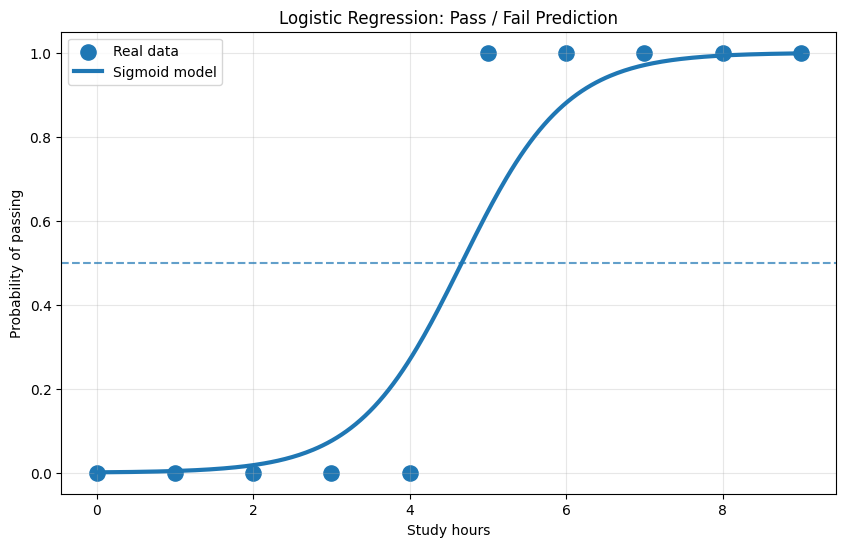

In [4]:
plt.figure(figsize=(10,6))

# Real data
plt.scatter(x, y, s=120, label="Real data")

# Smooth sigmoid curve
x_curve = np.linspace(0, 9, 300)
z_curve = weight * x_curve + bias
p_curve = 1 / (1 + np.exp(-z_curve))

plt.plot(x_curve, p_curve, linewidth=3, label="Sigmoid model")

# Decision threshold
plt.axhline(0.5, linestyle="--", alpha=0.7)

plt.xlabel("Study hours")
plt.ylabel("Probability of passing")
plt.title("Logistic Regression: Pass / Fail Prediction")

plt.grid(True, alpha=0.3)
plt.legend()

plt.show()

Questions

1. What does the weight control?
2. What does the bias control?
3. What happens when the sigmoid becomes steeper?
4. Where is the decision boundary?
5. Which students are difficult to classify?
6. Why is logistic regression better than linear regression here?

Answers

1. The weight controls the steepness of the sigmoid curve
2. The bias moves the curve horizontally
3. The model becomes more confident
4. The decision boundary is where the probability equals 0.5
5. The students who study 4 to 5 hours, because they are at the transition zone of the curve
6. Logistic Regression outputs 0 and 1, which is good for classification problems

## Part B — Use a Real Dataset

Now repeat the same process using a real dataset.

Choose:

- one numerical column as `x`
- one binary column as `y`

Below are beginner-friendly datasets you can use.

| Dataset | Link | Example `x` | Example `y` | Task |
|---|---|---|---|---|
| Titanic | [Open dataset](https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv) | `Age`, `Fare` | `Survived` | Predict survival |
| Breast Cancer Wisconsin | [Open dataset](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_breast_cancer.html) | `mean radius`, `mean texture` | `target` | Benign vs malignant |
| Heart Disease | [Open dataset](https://archive.ics.uci.edu/dataset/45/heart+disease) | `cholesterol`, `age` | `disease` | Predict heart disease |
| Palmer Penguins | [Open dataset](https://github.com/allisonhorst/palmerpenguins) | `bill_length_mm`, `body_mass_g` | species converted to binary | Classify penguin species |
| Student Performance | [Open dataset](https://archive.ics.uci.edu/dataset/320/student+performance) | `studytime`, `absences` | pass/fail from final grade | Predict pass/fail |
| SMS Spam | [Open dataset](https://archive.ics.uci.edu/dataset/228/sms+spam+collection) | message length, number of keywords | spam / ham | Spam detection |

### Suggested choice 

Use the **Titanic dataset** first:

In [5]:
import pandas as pd

url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


### Your Real-Data Task

1. Load the dataset.
2. Display the first rows with df.head().
3. Choose one feature x.
4. Choose one binary target y.
5. Plot the data.
6. Try different values of weight and bias.
7. Observe how the sigmoid changes.
8. Compare your intuition with Python’s logistic regression model.

In [8]:

x_data = df['Age'].dropna()
y_data = df.loc[x_data.index, 'Survived']

x = np.array(x_data)
y = np.array(y_data)

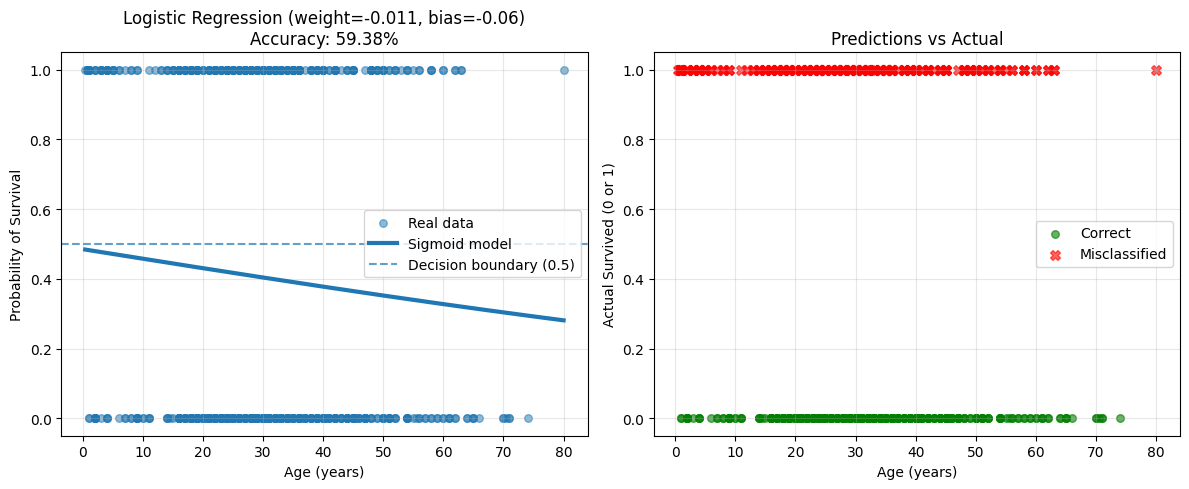

Accuracy: 59.38%
Decision boundary at Age: -5.5 years


In [11]:
weight = -0.011
bias = -0.06

# Linear part
z = weight * x + bias

# Sigmoid
p = 1 / (1 + np.exp(-z))

# Predicted classes
y_pred = (p > 0.5).astype(int)

# Calculate accuracy
accuracy = (y_pred == y).mean()

# Plot
plt.figure(figsize=(12, 5))

# Plot 1: Data and sigmoid
plt.subplot(1, 2, 1)
plt.scatter(x, y, alpha=0.5, s=30, label="Real data")

# Smooth sigmoid curve
x_curve = np.linspace(x.min(), x.max(), 300)
z_curve = weight * x_curve + bias
p_curve = 1 / (1 + np.exp(-z_curve))
plt.plot(x_curve, p_curve, linewidth=3, label="Sigmoid model")
plt.axhline(0.5, linestyle="--", alpha=0.7, label="Decision boundary (0.5)")
plt.xlabel("Age (years)")
plt.ylabel("Probability of Survival")
plt.title(f"Logistic Regression (weight={weight}, bias={bias:.2f})\nAccuracy: {accuracy:.2%}")
plt.legend()
plt.grid(True, alpha=0.3)

# Plot 2: Predictions vs actual
plt.subplot(1, 2, 2)
errors = (y_pred != y)
plt.scatter(x[~errors], y[~errors], c='green', alpha=0.6, s=30, label="Correct")
plt.scatter(x[errors], y[errors], c='red', alpha=0.6, s=50, marker='X', label="Misclassified")
plt.xlabel("Age (years)")
plt.ylabel("Actual Survived (0 or 1)")
plt.title("Predictions vs Actual")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Accuracy: {accuracy:.2%}")
print(f"Decision boundary at Age: {-bias/weight:.1f} years")

In [12]:
from sklearn.linear_model import LogisticRegression

X = x.reshape(-1, 1)  # Reshape for sklearn
model = LogisticRegression()
model.fit(X, y)

y_pred_sklearn = model.predict(X)
y_proba_sklearn = model.predict_proba(X)[:, 1]
accuracy_sklearn = model.score(X, y)

sklearn_weight = model.coef_[0][0]
sklearn_bias = model.intercept_[0]

print(f"\nManual model:")
print(f"  Weight: {weight}")
print(f"  Bias: {bias:.4f}")
print(f"  Accuracy: {accuracy:.2%}")
print(f"  Decision boundary: {-bias/weight:.2f} years")

print(f"\nSklearn model:")
print(f"  Weight: {sklearn_weight:.6f}")
print(f"  Bias: {sklearn_bias:.4f}")
print(f"  Accuracy: {accuracy_sklearn:.2%}")
print(f"  Decision boundary: {-sklearn_bias/sklearn_weight:.2f} years")


Manual model:
  Weight: -0.011
  Bias: -0.0600
  Accuracy: 59.38%
  Decision boundary: -5.45 years

Sklearn model:
  Weight: -0.010963
  Bias: -0.0567
  Accuracy: 59.38%
  Decision boundary: -5.18 years
